In [36]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

In [37]:
# Load dataset
df = pd.read_csv('/content/Mall_Customers.csv')

# Show first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [38]:
# Drop customer ID
df = df.drop('CustomerID', axis=1)

In [39]:
# Convert Gender into numeric
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [40]:
# Missing values
print(df.isnull().sum())

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [41]:
# Fill missing values using mean
imputer = SimpleImputer(strategy='mean')

df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

In [42]:
# Feature scaling
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_imputed)

In [43]:
# Apply PCA
pca = PCA()

pca_data = pca.fit_transform(scaled_data)

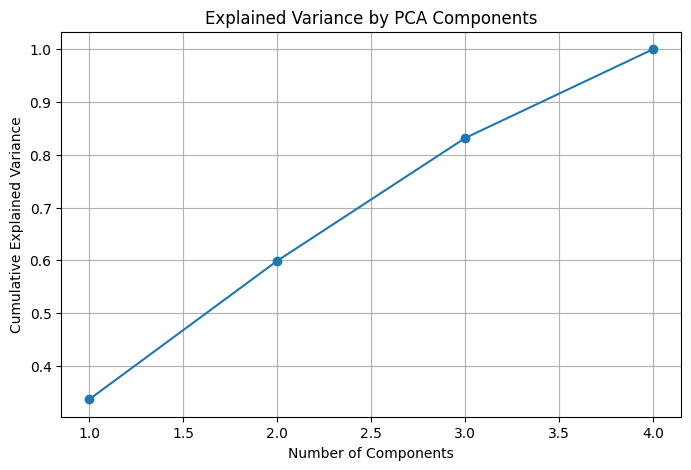

In [44]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Plot
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance.cumsum(),
    marker='o'
)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)

plt.show()

In [45]:
# PCA with 2 components
pca_2 = PCA(n_components=2)

principal_components = pca_2.fit_transform(scaled_data)

# Create dataframe
pca_df = pd.DataFrame(
    data=principal_components,
    columns=['PC1', 'PC2']
)

pca_df.head()

,PC1,PC2
0,-0.406383,-0.520714
1,-1.427673,-0.367310
2,0.050761,-1.894068
3,-1.694513,-1.631908
4,-0.313108,-1.810483


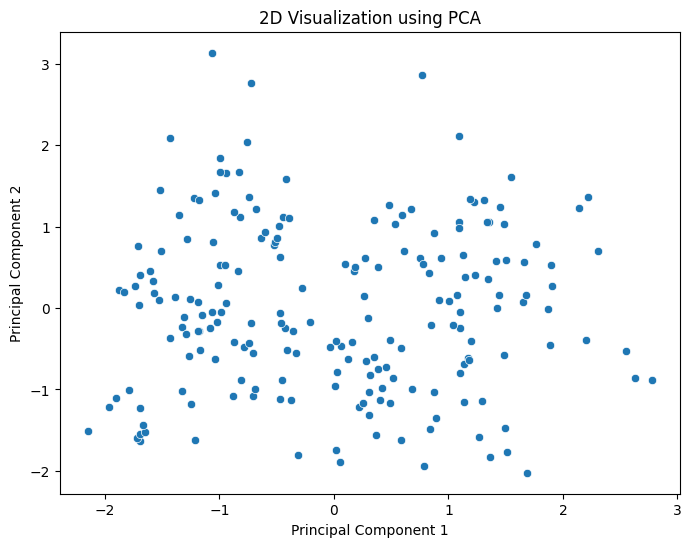

In [46]:
# Scatter plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    data=pca_df
)

plt.title('2D Visualization using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

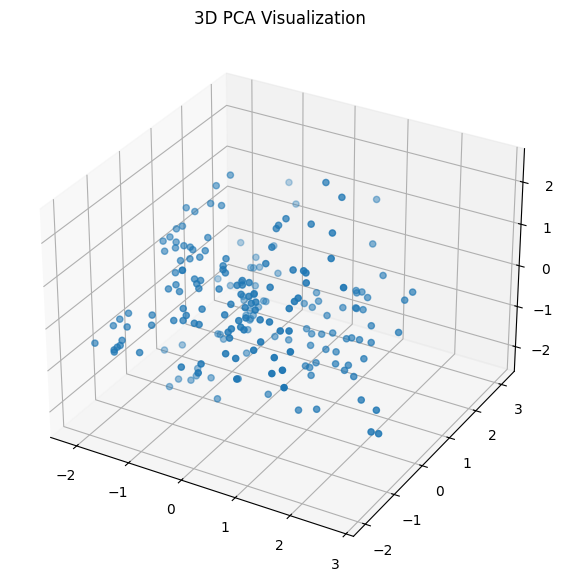

In [47]:
from mpl_toolkits.mplot3d import Axes3D

# PCA with 3 components
pca_3 = PCA(n_components=3)

pca_result_3d = pca_3.fit_transform(scaled_data)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    pca_result_3d[:,0],
    pca_result_3d[:,1],
    pca_result_3d[:,2]
)

ax.set_title("3D PCA Visualization")

plt.show()

Question - 2


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [49]:
# Load dataset
sales_df = pd.read_csv('/content/train.csv')

sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [50]:
import pandas as pd

# Load dataset
sales_df = pd.read_csv('train.csv')

# Convert Order Date column to datetime
sales_df['Order Date'] = pd.to_datetime(
    sales_df['Order Date'],
    dayfirst=True
)

# Set as index
sales_df.set_index('Order Date', inplace=True)

# Sort by date
sales_df.sort_index(inplace=True)

# Display first rows
sales_df.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
Order Date,,,,,,,,,,,,,,,,,
2015-01-03,7981,CA-2015-103800,07/01/2015,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095.0,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448
2015-01-04,742,CA-2015-112326,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540
2015-01-04,741,CA-2015-112326,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736
2015-01-04,740,CA-2015-112326,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784
2015-01-05,1760,CA-2015-141817,12/01/2015,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143.0,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536


In [51]:
# Check missing values
print(sales_df.isnull().sum())

# Fill missing values
sales_df.fillna(method='ffill', inplace=True)

Row ID            0
Order ID          0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


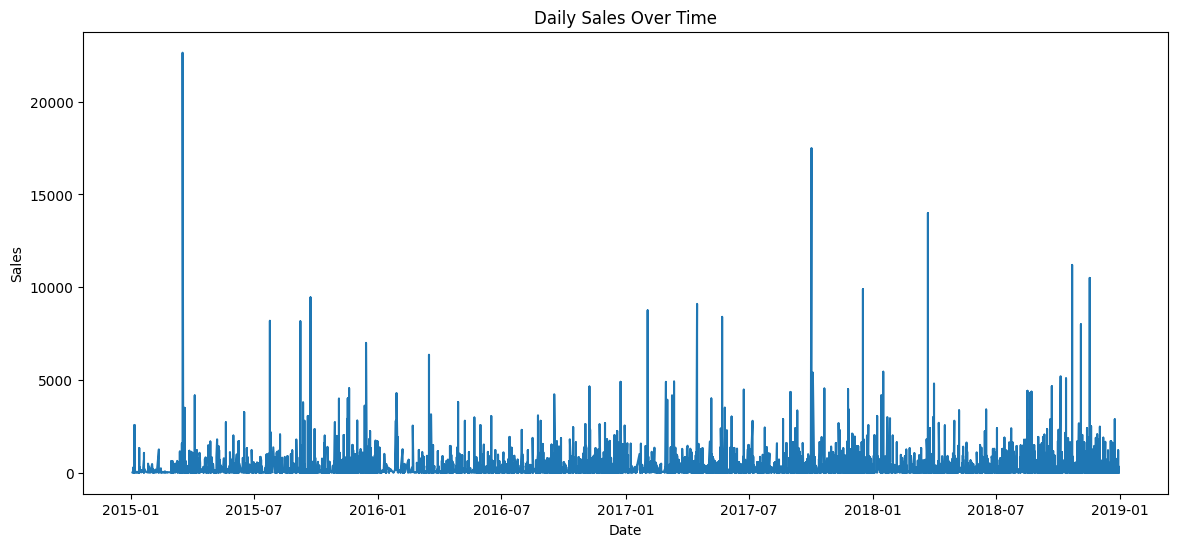

In [52]:
plt.figure(figsize=(14,6))

plt.plot(sales_df['Sales'])

plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

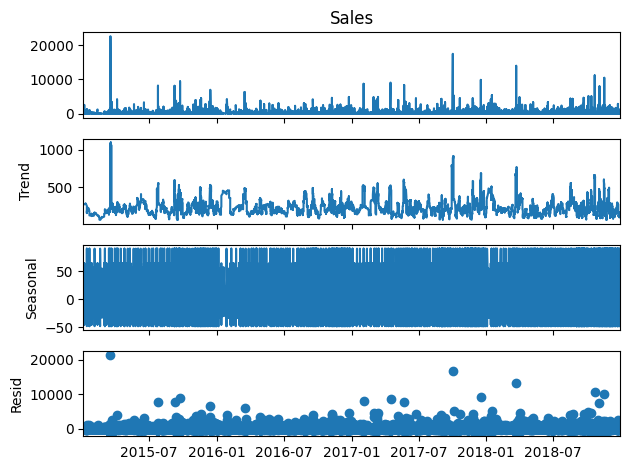

In [53]:
decomposition = seasonal_decompose(
    sales_df['Sales'],
    model='additive',
    period=30
)

decomposition.plot()

plt.show()

In [54]:
result = adfuller(sales_df['Sales'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -99.08279579913294
p-value: 0.0


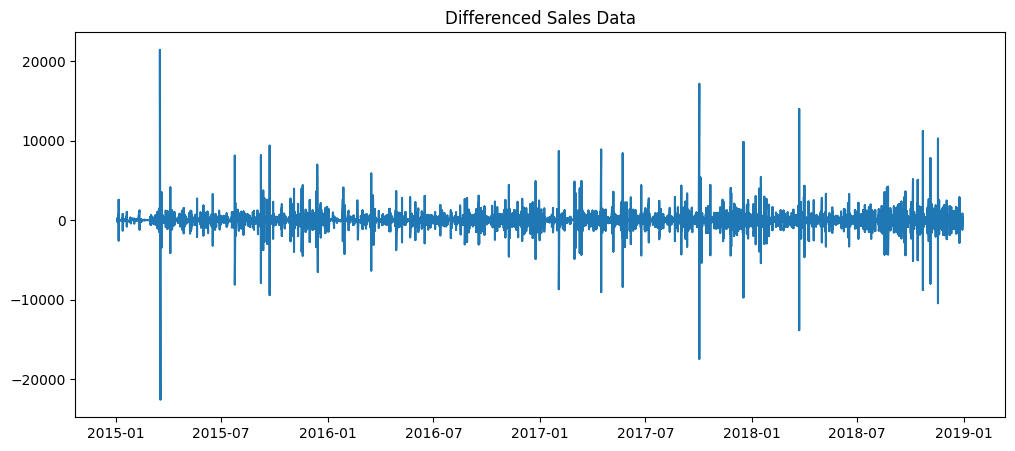

In [55]:
sales_diff = sales_df['Sales'].diff().dropna()

# Plot differenced data
plt.figure(figsize=(12,5))

plt.plot(sales_diff)

plt.title('Differenced Sales Data')

plt.show()

In [56]:
train = sales_df['Sales'][:-30]
test = sales_df['Sales'][-30:]

In [57]:
# Build model
model = ARIMA(train, order=(5,1,2))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                 9770
Model:                 ARIMA(5, 1, 2)   Log Likelihood              -76794.205
Date:                Mon, 04 May 2026   AIC                         153604.410
Time:                        19:22:25   BIC                         153661.906
Sample:                             0   HQIC                        153623.895
                               - 9770                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0010      0.057    -17.451      0.000      -1.113      -0.889
ar.L2          0.0033      0.017      0.193      0.847      -0.031       0.037
ar.L3          0.0030      0.020      0.153      0.8

In [58]:
forecast = model_fit.forecast(steps=30)

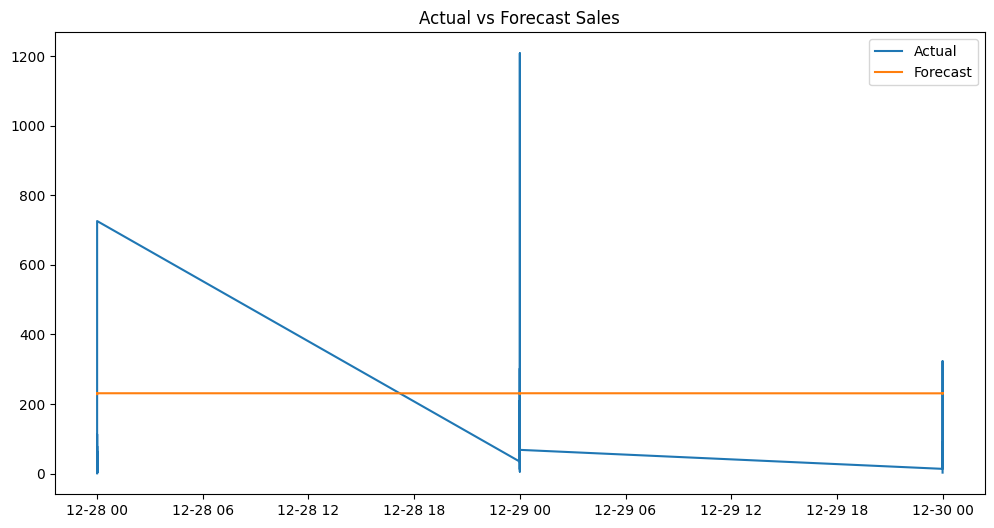

In [59]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.title('Actual vs Forecast Sales')

plt.legend()

plt.show()

In [61]:
mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 201.06651941549447
RMSE: 262.6716770776998
